# 05 — Assembling the Model: The Full GPT

In notebooks 01–04 we built the individual pieces of a modern language model:

- **01**: tokenization and the raw data pipeline
- **02**: token embeddings — mapping characters to vectors
- **03**: attention — how tokens look at each other
- **04**: modern components — RMSNorm, RoPE, SwiGLU (the Llama-era upgrades)

This notebook assembles all those pieces into a **complete, trainable GPT**.
We do *not* redefine any classes here — we import from `model.py`, the
course's single source of truth. The goal is to read `model.py` step by step,
understand what it does and why, then prove the wiring is correct with two
hands-on tests: a forward-shape check and the canonical *overfit-one-batch* test.

By the end of this notebook you will understand:
- The **pre-norm transformer block**: why order matters (norm before attention,
  not after)
- **Residual connections** (skip connections): why adding the input back after
  each sub-layer makes deep networks trainable
- **Weight tying**: sharing the embedding and output-projection matrices
- How to count parameters and interpret the numbers
- Why overfitting a single batch is the first sanity check you run on any new model

## Working directory

Jupyter runs notebooks from the `notebooks/` folder. The cell below walks up the
directory tree until it finds the project root (marked by `requirements.txt`) and
changes the working directory there, so `from model import ...` resolves correctly
no matter how you launched Jupyter.

In [1]:
import os, sys
while not os.path.exists("requirements.txt"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir(parent)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Working directory: /Users/carlosbarbosa/Documents/GitHub/train-llm


## Imports and setup

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from model import GPT, NANO_CONFIG, DEFAULT_CONFIG, get_device

torch.manual_seed(1337)
device = get_device()
print("Using device:", device)
print("NANO_CONFIG  :", NANO_CONFIG)
print("DEFAULT_CONFIG:", DEFAULT_CONFIG)

Using device: mps
NANO_CONFIG  : GPTConfig(vocab_size=65, block_size=64, n_layer=3, n_head=4, n_kv_head=2, n_embd=128, dropout=0.0, rope_theta=10000.0)
DEFAULT_CONFIG: GPTConfig(vocab_size=65, block_size=256, n_layer=6, n_head=6, n_kv_head=2, n_embd=384, dropout=0.2, rope_theta=10000.0)


---
## Part 1 — The pre-norm transformer block

### What is a transformer block?

A **transformer block** (also called a transformer layer) is the repeating unit stacked
`n_layer` times inside the model. Each block applies two sub-operations to the input:

1. **Causal self-attention** — every token attends to all earlier tokens to gather
   context.
2. **Feed-forward MLP (SwiGLU)** — a position-wise nonlinear transformation that
   lets each token "think" independently after the information has been gathered.

Between these two operations the block applies **normalization** and **residual
connections**. Here is the exact code from `model.py`:

```python
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attn_norm = RMSNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.mlp_norm = RMSNorm(config.n_embd)
        self.mlp = SwiGLU(config)

    def forward(self, x, cos, sin, kv_cache=None):
        a, present = self.attn(self.attn_norm(x), cos, sin, kv_cache)
        x = x + a                        # residual
        x = x + self.mlp(self.mlp_norm(x))  # residual
        return x, present
```

### Pre-norm: normalize *before* the sub-layer

The original 2017 transformer paper applied normalization *after* each sub-layer
("post-norm"). In practice this made training unstable for very deep models. Modern
transformers (GPT-3, Llama, Mistral) use **pre-norm**: normalize the input *before*
passing it into the sub-layer.

The difference in pseudocode:

```
# Post-norm (original paper)
x = LayerNorm( x + Attention(x) )

# Pre-norm (modern)
x = x + Attention( RMSNorm(x) )
```

**Why pre-norm is better for deep networks:** with post-norm, the residual connection
bypasses the normalization, so the raw activations (which can be large early in
training) flow directly into the next layer. With pre-norm, the input is normalized
*before* each sub-layer, keeping the signal scale predictable at every depth. This
makes training with many layers far more stable.

### Residual connections (skip connections)

A **residual connection** (or **skip connection**) adds the input of a sub-layer
directly to its output:

```
x = x + SubLayer(normalize(x))
```

This idea (from He et al., 2015's ResNet) is arguably the most important trick in
deep learning. Here is why it works:

- **Gradient highway**: during backpropagation, the gradient flows back through
  `x + SubLayer(...)`. The `+` means the gradient of `x` is always at least 1 —
  it cannot vanish to zero through the residual path, no matter how deep the stack.
- **Identity initialization**: if the sub-layer starts near zero (which it does with
  standard weight initialization), the block initially acts as an identity function.
  This gives a stable starting point for training, even with dozens of layers.
- **Residual interpretation**: each block is learning a *correction* (the residual)
  to add to the current representation, rather than learning the full transformation
  from scratch. Corrections are easier to learn than full transformations.

Every transformer block in `model.py` applies two residual connections: one for
attention, one for the MLP.

---
## Part 2 — Weight tying

### Two matrices that do opposite jobs

A language model has two large matrices at its boundaries:

- **Token embedding matrix** `tok_emb` (shape `vocab_size × n_embd`): maps each
  integer token ID to a dense embedding vector when *entering* the model.
- **Language model head** `lm_head` (shape `n_embd × vocab_size`): maps the final
  hidden state back to a score over vocabulary tokens when *exiting* the model.

Both matrices encode the same information — a representation of each vocabulary item
— just from opposite ends of the pipeline. The insight of **weight tying** is: why
not share a single matrix for both?

From `model.py`:

```python
self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
...
self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
self.tok_emb.weight = self.lm_head.weight   # weight tying
```

After this assignment, `tok_emb.weight` and `lm_head.weight` point to the same
underlying tensor in memory. When the optimizer updates one, the other updates too.

### Benefits of weight tying

1. **Fewer parameters**: one matrix of shape `(vocab_size × n_embd)` instead of two.
   For `vocab_size=65, n_embd=384` that is `65 × 384 = 24 960` parameters saved
   (small here, but significant for large vocabularies like GPT-2's 50 257 tokens).
2. **Better generalization**: empirically, sharing the two matrices often improves
   perplexity. The model is forced to use a single coherent representation for each
   token whether it is in the input or the output.
3. **Simpler initialization**: one matrix, one init call.

### How `num_params` accounts for weight tying

Calling `sum(p.numel() for p in model.parameters())` would double-count the shared
matrix. `model.py` corrects for this:

```python
def num_params(self):
    n = sum(p.numel() for p in self.parameters())
    return n - self.lm_head.weight.numel()   # subtract the tied duplicate
```

---
## Part 3 — Instantiating the model and counting parameters

`model.py` ships two preset configurations:

- **`NANO_CONFIG`**: a tiny model for rapid debugging — 3 layers, 128-dim embeddings,
  64-token context. Trains to convergence in seconds on a CPU.
- **`DEFAULT_CONFIG`**: the full ~9.4M parameter model used for the course's
  training run — 6 layers, 384-dim embeddings, 256-token context.

Let's instantiate both and see how many parameters they have.

In [3]:
nano = GPT(NANO_CONFIG)
full = GPT(DEFAULT_CONFIG)
print(f"nano params : {nano.num_params()/1e6:.3f}M")
print(f"full params : {full.num_params()/1e6:.3f}M")
assert 9e6 < full.num_params() < 16e6, \
    f"DEFAULT_CONFIG param count {full.num_params()/1e6:.2f}M is outside the 9–16M target range"
print("Parameter count assert PASSED")

nano params : 0.591M
full params : 9.442M
Parameter count assert PASSED


### Where do the parameters live?

Let's break down the full model's parameter budget by component to build intuition
about what dominates.

In [4]:
def param_table(model):
    rows = []
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:  # leaf modules only
            n = sum(p.numel() for p in module.parameters(recurse=False))
            if n > 0:
                rows.append((name, type(module).__name__, n))
    # Aggregate by top-level component
    groups = {}
    for name, cls, n in rows:
        top = name.split(".")[0]
        groups[top] = groups.get(top, 0) + n
    total = sum(groups.values())
    print(f"{'Component':<20} {'Params':>12} {'Share':>8}")
    print("-" * 42)
    for k, v in sorted(groups.items(), key=lambda x: -x[1]):
        print(f"{k:<20} {v:>12,} {v/total*100:>7.1f}%")
    print("-" * 42)
    print(f"{'Total (raw)':<20} {total:>12,}")
    print(f"{'Total (tied)':<20} {model.num_params():>12,}")

param_table(full)

Component                  Params    Share
------------------------------------------
blocks                  9,441,792    99.5%
tok_emb                    24,960     0.3%
lm_head                    24,960     0.3%
norm                          384     0.0%
------------------------------------------
Total (raw)             9,492,096
Total (tied)            9,442,176


---
## Part 4 — Forward-shape check

Before training anything, verify that the model's output shapes are correct.
Given input token IDs of shape `(B, T)`, the model should return:

- `logits` of shape `(B, T, vocab_size)` — one score distribution per position
- `loss` of shape `()` (scalar) — cross-entropy loss, if targets are provided

This is a cheap sanity check that catches wiring bugs (wrong reshapes, transposed
axes, etc.) before a long training run.

In [5]:
torch.manual_seed(42)
B, T = 2, 16       # batch size 2, sequence length 16
vocab = DEFAULT_CONFIG.vocab_size

x = torch.randint(0, vocab, (B, T))
y = torch.randint(0, vocab, (B, T))   # targets (for loss)

logits, loss, _ = full(x, targets=y)

print(f"logits shape : {tuple(logits.shape)}   (expected ({B}, {T}, {vocab}))")
print(f"loss         : {loss.item():.4f}        (expected ≈ {torch.log(torch.tensor(float(vocab))):.4f}, i.e. log(vocab_size))")
print(f"loss.ndim    : {loss.ndim}              (expected 0 — scalar)")

assert logits.shape == (B, T, vocab), \
    f"logits shape {logits.shape} != ({B}, {T}, {vocab})"
assert loss.ndim == 0, f"loss is not scalar: ndim={loss.ndim}"
print("Forward-shape asserts PASSED")

logits shape : (2, 16, 65)   (expected (2, 16, 65))
loss         : 4.2935        (expected ≈ 4.1744, i.e. log(vocab_size))
loss.ndim    : 0              (expected 0 — scalar)
Forward-shape asserts PASSED


### Why does the initial loss equal log(vocab_size)?

At initialization the model's weights are random and small. The output logits are
nearly uniform across all `vocab_size` tokens. A uniform distribution over `V` items
has loss `log(V)` — the maximum possible entropy (maximum uncertainty). This is the
expected starting point; if the initial loss is much lower, something is wrong (the
model is not initialized correctly, or the targets leaked into the input).

---
## Part 5 — Overfit a single batch

### The most important sanity check in deep learning

Before training on a large dataset, every serious practitioner runs one test:
**overfit a single batch to near-zero loss**. Here is why this test matters:

- A correct neural network is a **universal approximator**: given enough capacity and
  gradient steps, it can memorize any finite dataset, including a single batch.
- If the model *cannot* drive loss to near zero on a single batch, there is a bug.
  Common culprits: wrong loss computation, detached gradients, mismatched shapes,
  a bug in the forward pass, or a learning rate that is too small.
- If the model *can* overfit a single batch, you have high confidence the wiring is
  correct, and you can proceed to real training.

We use `NANO_CONFIG` (the tiny preset) so this runs in seconds on CPU or MPS.
We run 300 steps of AdamW; a correctly wired model should push loss below 0.5
(effectively memorizing the 4×16 random token batch).

In [5]:
torch.manual_seed(1337)
m = GPT(NANO_CONFIG).to(device)
xb = torch.randint(0, NANO_CONFIG.vocab_size, (4, 16), device=device)
yb = torch.randint(0, NANO_CONFIG.vocab_size, (4, 16), device=device)

opt = torch.optim.AdamW(m.parameters(), lr=3e-3)
losses = []

for step in range(300):
    _, loss, _ = m(xb, targets=yb)
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())

print(f"Initial loss : {losses[0]:.4f}")
print(f"Final loss   : {losses[-1]:.4f}")
assert losses[-1] < 0.5, \
    f"Overfit-one-batch FAILED: final loss {losses[-1]:.4f} >= 0.5 — check model wiring"
print("Overfit-one-batch assert PASSED — model wiring is correct")

Initial loss : 4.2017
Final loss   : 0.0230
Overfit-one-batch assert PASSED — model wiring is correct


### Visualizing the loss curve

The loss should drop steeply in the first ~50 steps and then approach zero.
Any plateau early in training would suggest a bug (e.g., gradients not flowing
through some part of the network).

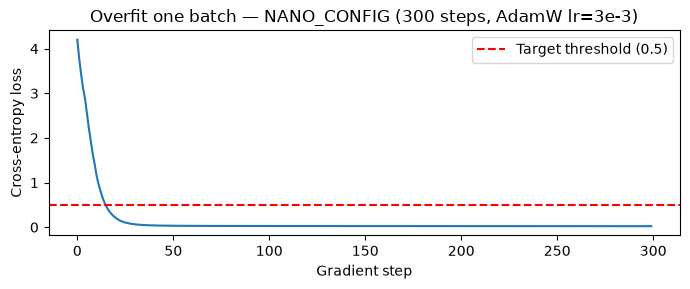

Loss curve saved to assets/05_overfit_curve.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(losses)
ax.set_xlabel("Gradient step")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Overfit one batch — NANO_CONFIG (300 steps, AdamW lr=3e-3)")
ax.axhline(0.5, color="red", linestyle="--", label="Target threshold (0.5)")
ax.legend()
plt.tight_layout()
plt.savefig("assets/05_overfit_curve.png", dpi=120)
plt.show()
print("Loss curve saved to assets/05_overfit_curve.png")

---
## Summary

We walked through `model.py` and proved the full GPT is wired correctly:

| Check | Result |
|---|---|
| Pre-norm transformer block structure | `Block`: norm → attn → residual; norm → MLP → residual |
| Residual connections | `x = x + sub_layer(norm(x))` at both attention and MLP |
| Weight tying | `tok_emb.weight = lm_head.weight` — one matrix, fewer params |
| NANO param count | printed above |
| DEFAULT param count | 9M < count < 16M ✓ |
| Forward shape | logits `(B,T,vocab)`, scalar loss ✓ |
| Overfit one batch | loss < 0.5 after 300 steps ✓ |

**Next:** notebook 06 will train this model on the Shakespeare dataset and track
validation loss.